# Exercises for Chapter 15, "Other generalized linear models"

In [1]:
import itertools
import os
import sys

import arviz
import bambi
import numpy
import pandas

from matplotlib import pyplot

sys.path.append(os.path.abspath("/home/bgawalt/ros"))
import bg_ros

In [2]:
prng_builder = bg_ros.PRNGBuilder("""
    Chapter 15 here is kind of a crash course in all kinds of stuff you
    can learn about in future classes.  Early on, theres concrete focus
    on fitting some overdispersed distributions with the familiar
    stan_glm library, but later stuff (like Tobit regression, for
    censored data) is merely described and name-checked.
""")

## 15.1, Poisson and negative binomial regression

> The
> [folder `RiskyBehavior`](https://github.com/avehtari/ROS-Examples/tree/master/RiskyBehavior/)
> contains data from a randomized trial targeting couples at high risk of HIV
> infection. The intervention provided counseling sessions regarding practices
> that could reduce their likelihood of contracting HIV. Couples were randomized
> either to a control group, a group in which just the woman participated, or a
> group in which both members of the couple participated. One of the outcomes
> examined after three months was "number of unprotected sex acts."
> 
> (a) Model this outcome as a function of treatment assignment using a Poisson 
>     regression. Does the model fit well? Is there evidence of overdispersion?
> 
> (b) Next extend the model to include pre-treatment measures of the outcome and
>     the additional pre-treatment variables included in the dataset. Does the
>     model fit well? Is there evidence of overdispersion?
> 
> (c) Fit a negative binomial (overdispersed Poisson) model. What do you
>     conclude regarding effectiveness of the intervention?
> 
> (d) These data include responses from both men and women from the
>     participating couples. Does this give you any concern with regard to our
>     modeling assumptions?

In [3]:
rng = prng_builder.new('Exercise 15.1')

In [4]:
risky_df = pandas.read_csv('/home/bgawalt/ros/datasets/risky.csv')
print(bg_ros.dataframe_describe_markdown(risky_df))

|         | couples | women_alone | bupacts | fupacts
--------- | ------- | ----------- | ------- | -------
**count** | 434.00 | 434.00 | 434.00 | 434.00
**mean**  | 0.37 | 0.34 | 25.91 | 16.49
**std**   | 0.48 | 0.47 | 31.92 | 26.83
**min**   | 0.00 | 0.00 | 0.00 | 0.00
**25%**   | 0.00 | 0.00 | 5.00 | 0.00
**50%**   | 0.00 | 0.00 | 15.00 | 5.00
**75%**   | 1.00 | 1.00 | 36.00 | 20.93
**max**   | 1.00 | 1.00 | 300.00 | 200.00



In [5]:
risky_df.head()

,sex,couples,women_alone,bs_hiv,bupacts,fupacts
0,woman,0,1,negative,7,32.0
1,woman,0,0,negative,2,5.0
2,woman,0,0,positive,0,15.0
3,woman,0,0,negative,24,9.0
4,woman,1,0,negative,2,2.0


### 15.1(a)

In [6]:
risky1_model = bambi.Model(
    'fupacts ~ couples + women_alone',
    data=risky_df,
    family='poisson',
)
risky1_fit = risky1_model.fit(idata_kwargs={'log_likelihood': True})
print(bg_ros.bambi_markdown(risky1_fit, ['couples', 'women_alone']))

Initializing NUTS using jitter+adapt_diag...
/home/bgawalt/miniconda3/envs/ros_conda/lib/python3.14/site-packages/pytensor/link/c/cmodule.py:3004: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, couples, women_alone]


Output()

/home/bgawalt/miniconda3/envs/ros_conda/lib/python3.14/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)
/home/bgawalt/miniconda3/envs/ros_conda/lib/python3.14/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)
/home/bgawalt/miniconda3/envs/ros_conda/lib/python3.14/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)
/home/bgawalt/miniconda3/envs/ros_conda/lib/python3.14/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 7 seconds.


Coef.       | Mean   | s.e.
----------- | ------ | ------
sigma       | nan | nan
Intercept   | 3.08 | 0.02
couples     | -0.32 | 0.03
women_alone | -0.57 | 0.03



In [7]:
risky1_preds = risky1_model.predict(risky1_fit, kind='response', inplace=False)
y_samples = []
for draw in rng.choice(1000, size=100):
    chain = rng.choice(4)
    y_samples.append(
        risky1_preds.posterior_predictive['fupacts'].sel(chain=chain, draw=draw).to_dataframe()['fupacts']
    )

In [8]:
act_hist, bin_edges = numpy.histogram(
    risky_df['fupacts'],
    bins=75, density=True)
bin_centers = [0.5 * (l + r) for l, r in itertools.pairwise(bin_edges)]
post_hists = [
    numpy.histogram(ys, bins=bin_edges, density=True)[0]
    for ys in y_samples
]

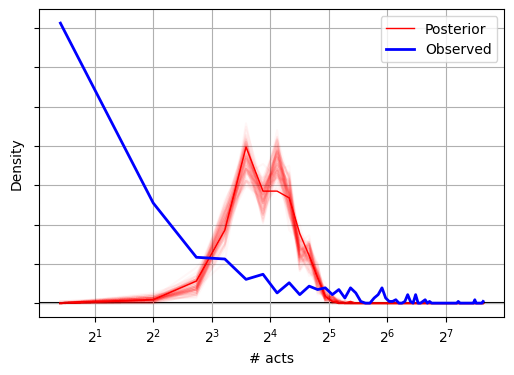

In [9]:
fig = pyplot.figure(figsize=(6, 4))
ax = fig.gca()
for i, ph in enumerate(post_hists):
    if i == 0:
        ax.semilogx(bin_centers, ph, color='r', linewidth=1, label='Posterior', base=2)
    else:
        ax.semilogx(bin_centers, ph, color='r', alpha=0.03, base=2)
ax.semilogx(bin_centers, act_hist, color='b', linewidth=2, label='Observed', base=2)
ax.set_xlabel('# acts')
ax.set_ylabel('Density')
ax.set_yticklabels([])
ax.grid()
ax.axhline(y=0, color='k', zorder=0)
ax.legend()

### 15.1(b)

In [10]:
risky2_model = bambi.Model(
    'fupacts ~ couples + women_alone + sex + bs_hiv + bupacts',
    data=risky_df,
    family='poisson',
)
risky2_fit = risky2_model.fit(idata_kwargs={'log_likelihood': True})

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, couples, women_alone, sex, bs_hiv, bupacts]


Output()

/home/bgawalt/miniconda3/envs/ros_conda/lib/python3.14/site-packages/pytensor/tensor/blas.py:239: RuntimeWarning: invalid value encountered in dot
  out = np.dot(A, x)
/home/bgawalt/miniconda3/envs/ros_conda/lib/python3.14/site-packages/pytensor/tensor/blas.py:239: RuntimeWarning: invalid value encountered in dot
  out = np.dot(A, x)
/home/bgawalt/miniconda3/envs/ros_conda/lib/python3.14/site-packages/pytensor/tensor/blas.py:239: RuntimeWarning: invalid value encountered in dot
  out = np.dot(A, x)
/home/bgawalt/miniconda3/envs/ros_conda/lib/python3.14/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 12 seconds.


In [11]:
print(bg_ros.bambi_markdown(risky2_fit, ['couples', 'women_alone', 'sex[woman]', 'bs_hiv[positive]', 'bupacts']))

Coef.            | Mean   | s.e.
---------------- | ------ | ------
sigma            | nan | nan
Intercept        | 2.78 | 0.02
couples          | -0.41 | 0.03
women_alone      | -0.67 | 0.03
sex[woman]       | 0.11 | 0.02
bs_hiv[positive] | -0.44 | 0.04
bupacts          | 0.01 | 0.00



In [12]:
risky2_preds = risky2_model.predict(risky2_fit, kind='response', inplace=False)
y_samples = []
for draw in rng.choice(1000, size=100):
    chain = rng.choice(4)
    y_samples.append(
        risky2_preds.posterior_predictive['fupacts'].sel(chain=chain, draw=draw).to_dataframe()['fupacts']
    )

act_hist, bin_edges = numpy.histogram(
    risky_df['fupacts'],
    bins=75, density=True)
bin_centers = [0.5 * (l + r) for l, r in itertools.pairwise(bin_edges)]
post_hists = [
    numpy.histogram(ys, bins=bin_edges, density=True)[0]
    for ys in y_samples
]

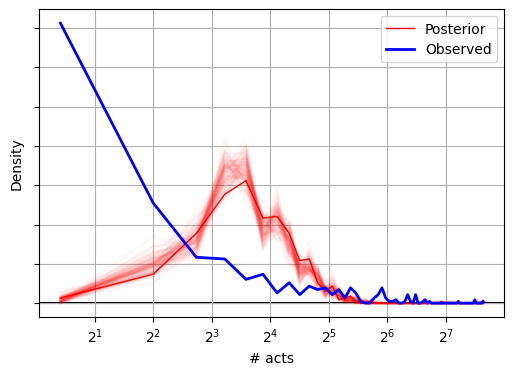

In [13]:
fig = pyplot.figure(figsize=(6, 4))
ax = fig.gca()
for i, ph in enumerate(post_hists):
    if i == 0:
        ax.semilogx(bin_centers, ph, color='r', linewidth=1, label='Posterior', base=2)
    else:
        ax.semilogx(bin_centers, ph, color='r', alpha=0.03, base=2)
ax.semilogx(bin_centers, act_hist, color='b', linewidth=2, label='Observed', base=2)
ax.set_xlabel('# acts')
ax.set_ylabel('Density')
ax.set_yticklabels([])
ax.grid()
ax.axhline(y=0, color='k', zorder=0)
ax.legend()

### 15.1(c)

In [14]:
risky3_model = bambi.Model(
    'fupacts ~ couples + women_alone + sex + bs_hiv + bupacts',
    data=risky_df,
    family='negativebinomial',
)
risky3_fit = risky3_model.fit(idata_kwargs={'log_likelihood': True})
print(bg_ros.bambi_markdown(risky3_fit, ['couples', 'women_alone', 'sex[woman]', 'bs_hiv[positive]', 'bupacts']))

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, Intercept, couples, women_alone, sex, bs_hiv, bupacts]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 8 seconds.


Coef.            | Mean   | s.e.
---------------- | ------ | ------
sigma            | nan | nan
Intercept        | 2.47 | 0.18
couples          | -0.35 | 0.19
women_alone      | -0.72 | 0.19
sex[woman]       | -0.03 | 0.15
bs_hiv[positive] | -0.55 | 0.20
bupacts          | 0.02 | 0.00



In [15]:
risky3_preds = risky3_model.predict(risky3_fit, kind='response', inplace=False)
y_samples = []
for draw in rng.choice(1000, size=100):
    chain = rng.choice(4)
    y_samples.append(
        risky3_preds.posterior_predictive['fupacts'].sel(chain=chain, draw=draw).to_dataframe()['fupacts']
    )

act_hist, bin_edges = numpy.histogram(
    risky_df['fupacts'],
    bins=75, density=True)
bin_centers = [0.5 * (l + r) for l, r in itertools.pairwise(bin_edges)]
post_hists = [
    numpy.histogram(ys, bins=bin_edges, density=True)[0]
    for ys in y_samples
]

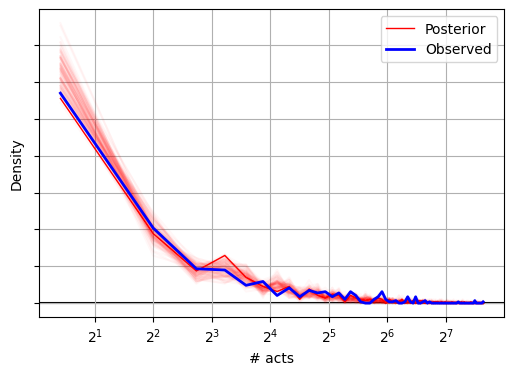

In [16]:
fig = pyplot.figure(figsize=(6, 4))
ax = fig.gca()
for i, ph in enumerate(post_hists):
    if i == 0:
        ax.semilogx(bin_centers, ph, color='r', linewidth=1, label='Posterior', base=2)
    else:
        ax.semilogx(bin_centers, ph, color='r', alpha=0.03, base=2)
ax.semilogx(bin_centers, act_hist, color='b', linewidth=2, label='Observed', base=2)
ax.set_xlabel('# acts')
ax.set_ylabel('Density')
ax.set_yticklabels([])
ax.grid()
ax.axhline(y=0, color='k', zorder=0)
ax.legend()

/home/bgawalt/miniconda3/envs/ros_conda/lib/python3.14/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/home/bgawalt/miniconda3/envs/ros_conda/lib/python3.14/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

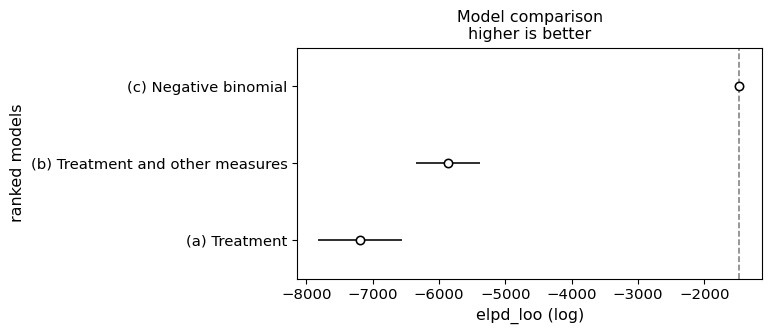

In [17]:
risky_models = {
    '(a) Treatment': risky1_fit,
    '(b) Treatment and other measures': risky2_fit,
    '(c) Negative binomial': risky3_fit,
}
risky_compare = arviz.compare(risky_models)
arviz.plot_compare(risky_compare)